### What it will be covered?
- Exploratory data analysis
- Data transformation for object detection
- Creating custom datasets
- Creating the model
- Defining the loss, optimizer, and IOU metric
- Training and evaluation of the model
- Deploying the model

In [1]:
import torch
import torchvision.transforms.functional as TF


import os
import pandas as pd
import seaborn as sns
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pylab as plt

from helper import *

# fix random seed
np.random.seed(2019)
# from matplotlib import rcParams

# figure size in inches
fig, ax = plt.subplots(figsize=(10, 5))
%matplotlib inline

### Exploratory Data Analysis

In [2]:
path2data="./data/"

# full path of labels file
path2labels=os.path.join(path2data,"Training400","Fovea_location.xlsx")

# maske sure to install xlrd
labels_df=pd.read_excel(path2labels,index_col="ID")

labels_df.head()

,ImgName,Fovea_X,Fovea_Y
ID,,,
1,g0001.jpg,1057.95,1076.52
2,g0002.jpg,1190.59,1017.09
3,g0003.jpg,1070.56,1084.85
4,g0004.jpg,1072.60,1035.48
5,g0005.jpg,1058.19,1100.33


In [3]:
print(len(labels_df))
labels_df.tail()

400


,ImgName,Fovea_X,Fovea_Y
ID,,,
396,n0356.jpg,1229.73,1043.89
397,n0357.jpg,1080.45,1081.30
398,n0358.jpg,1288.78,1122.37
399,n0359.jpg,1239.17,1077.17
400,n0360.jpg,1237.73,1089.06


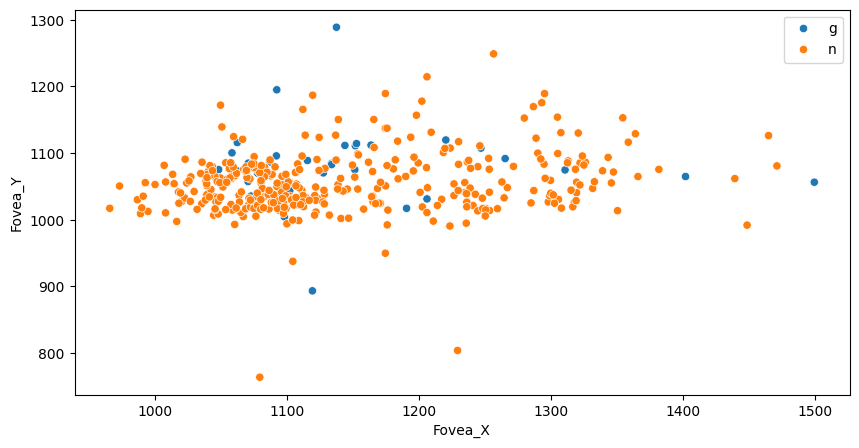

In [4]:
AorN=[imn[0] for imn in labels_df.ImgName]
sns.scatterplot(x=labels_df['Fovea_X'], y=labels_df['Fovea_Y'],hue=AorN)
plt.show()

In [5]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.subplots_adjust(wspace=0, hspace=0.3)
nrows,ncols=2,3

# get imgName column
imgName=labels_df["ImgName"]

# get ids
ids=labels_df.index

# select random ids
rndIds=np.random.choice(ids,nrows*ncols)
print(rndIds)



[ 73 371 160 294 217 191]


In [6]:
def load_img_label(labels_df,id_):    
    imgName=labels_df["ImgName"]    
    # if imgName[id_][0]=="A":
    #     prefix="Glaucoma"
    # else:
    #     prefix="Non-Glaucoma"
            
    fullPath2img=os.path.join(path2data,"Training400\Disc_Cup_Fovea_Illustration",imgName[id_])
    img = Image.open(fullPath2img)
    
    # centroid
    x=labels_df["Fovea_X"][id_]
    y=labels_df["Fovea_Y"][id_]
    
    label=(x,y)
    return img,label

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
C:\Users\maa\AppData\Local\Temp\ipykernel_8332\922121691.py:8: SyntaxWarning: invalid escape sequence '\D'
  fullPath2img=os.path.join(path2data,"Training400\Disc_Cup_Fovea_Illustration",imgName[id_])


(2124, 2056) (np.float64(1077.9), np.float64(1073.42))
(2124, 2056) (np.float64(1219.67), np.float64(1107.04))
(2124, 2056) (np.float64(1290.1), np.float64(1099.89))
(2124, 2056) (np.float64(1175.79), np.float64(1137.25))
(2124, 2056) (np.float64(1109.19), np.float64(1047.88))
(2124, 2056) (np.float64(1128.37), np.float64(1038.47))


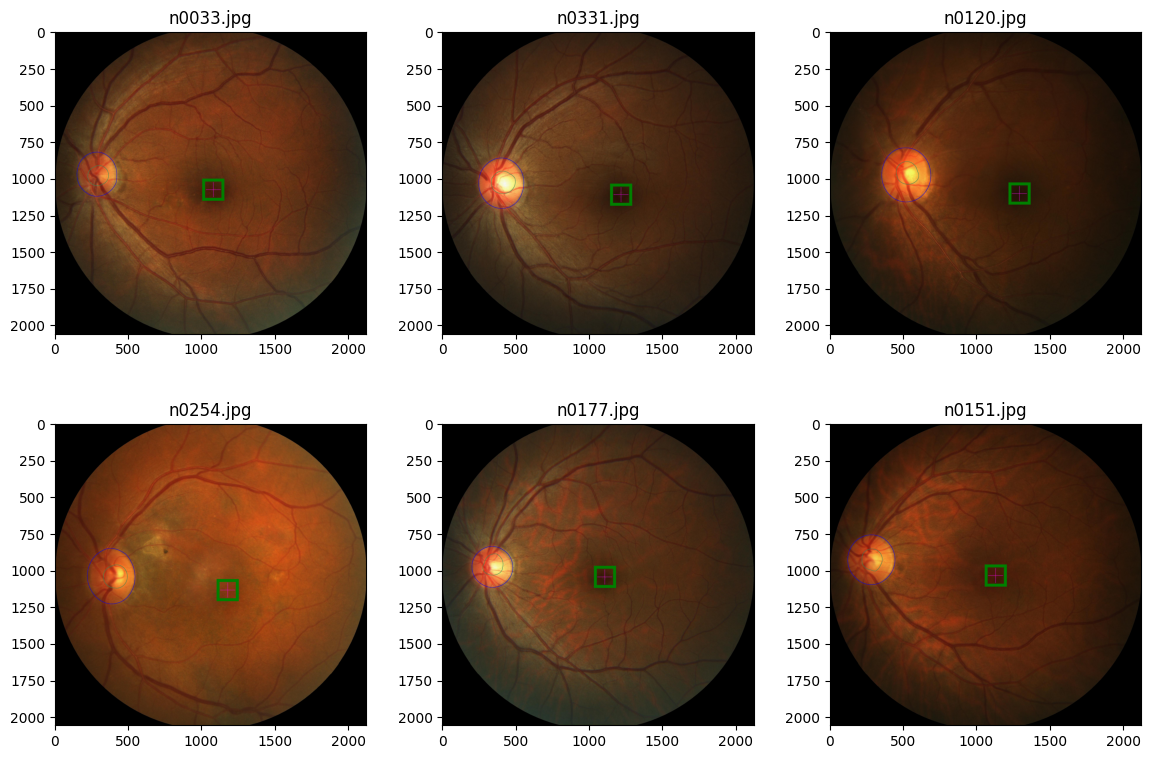

In [7]:
for i,id_ in enumerate(rndIds):
    
    img,label=load_img_label(labels_df,id_)   
    print(img.size,label)
    
    plt.subplot(nrows, ncols, i+1) 
    show_img_label(img,label,w_h=(150,150),thickness=20)
    plt.title(imgName[id_])
plt.show()

In [8]:
h_list,w_list=[],[]

for id_ in ids:
    full_path=os.path.join(path2data,"Training400/Disc_Cup_Fovea_Illustration",imgName[id_])

    img=Image.open(full_path)
    h,w=img.size
    h_list.append(h)
    w_list.append(w)

print(h)
print(w)

2124
2056


C:\Users\maa\AppData\Local\Temp\ipykernel_8332\2760052702.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a=h_list, kde=False)


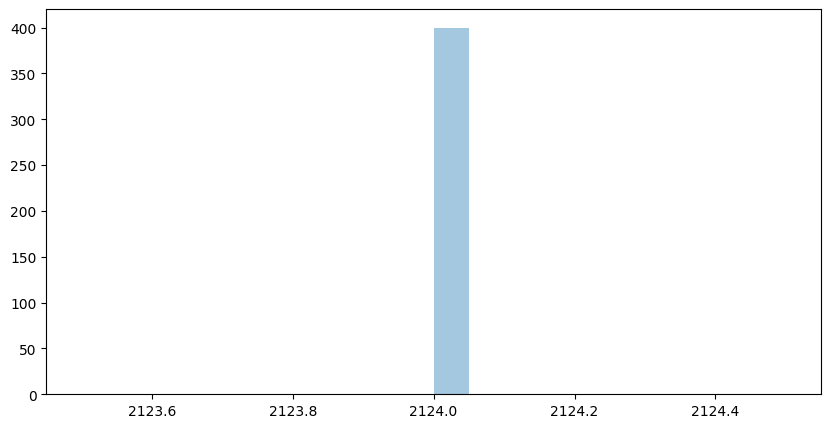

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.distplot(a=h_list, kde=False)
plt.show()

C:\Users\maa\AppData\Local\Temp\ipykernel_8332\1855833812.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a=w_list, kde=False)


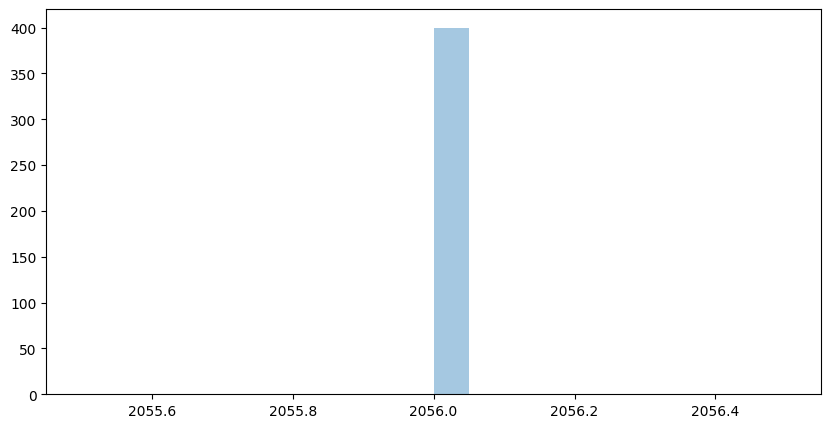

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.distplot(a=w_list, kde=False)
plt.show()

### Data Transformation for Object Detection

(2124, 2056) (np.float64(1057.95), np.float64(1076.52))
(256, 256) [127.51186 134.0414 ]


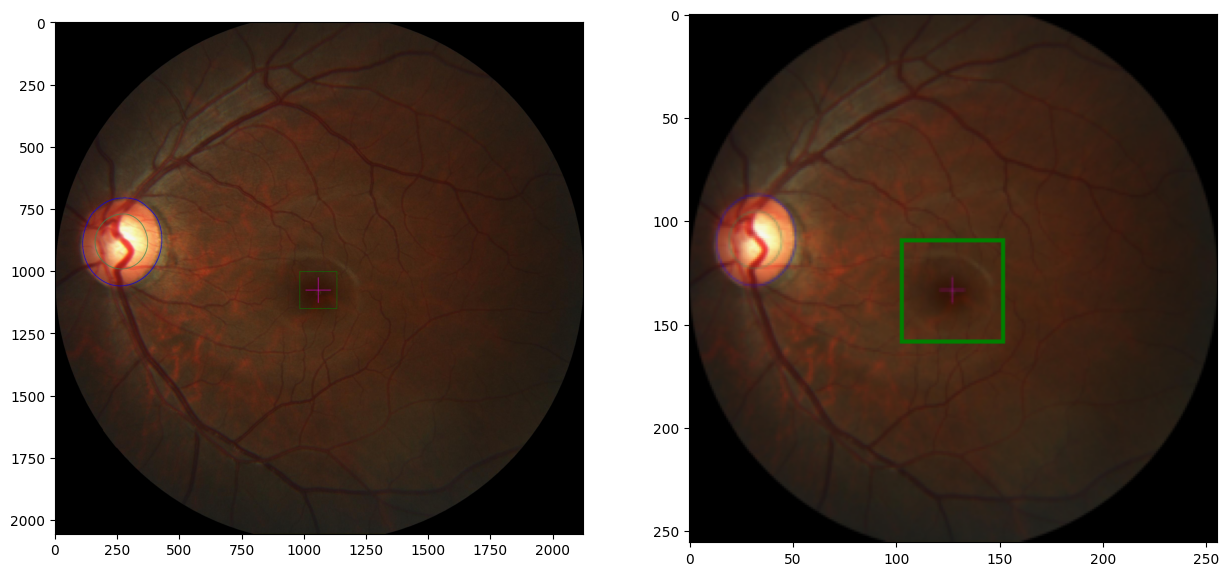

In [11]:
img,label = load_img_label(labels_df,1)
print(img.size,label)

img_r,label_r=resize_images(img,label)
print(img_r.size,label_r)

plt.clf
plt.subplot(1,2,1)
show_img_label(img,label,w_h=(150,150), thickness=2)
plt.subplot(1,2,2)
show_img_label(img_r,label_r, thickness=2)
plt.show()

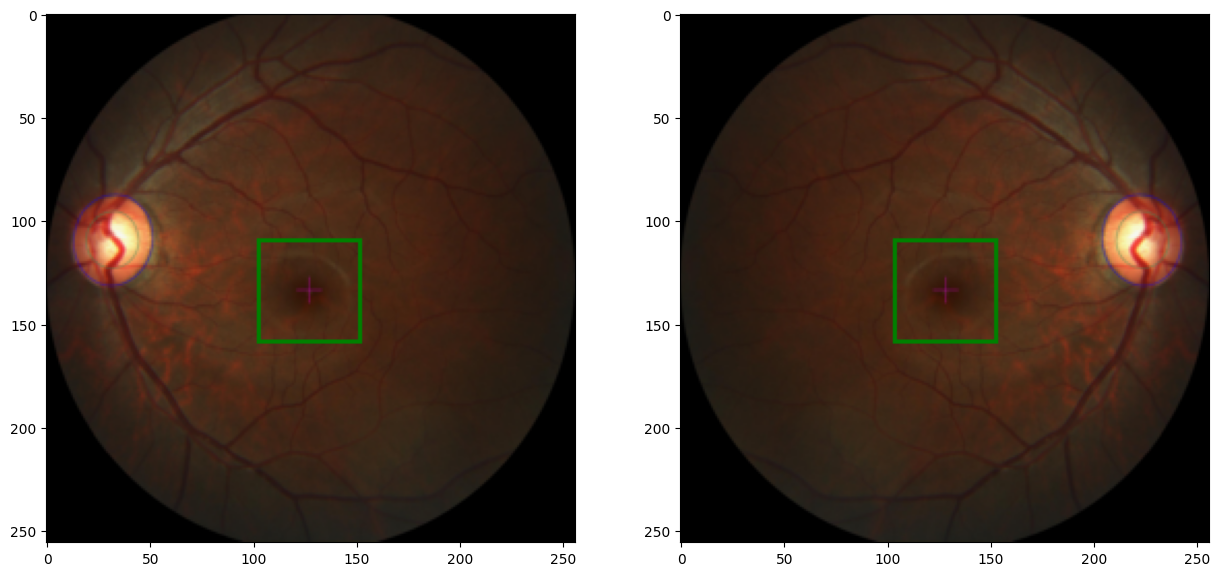

In [12]:
img, label=load_img_label(labels_df,1)
img_r,label_r=resize_images(img,label)
img_fh,label_fh=random_hflip(img_r,label_r)

plt.subplot(1,2,1)
show_img_label(img_r,label_r)
plt.subplot(1,2,2)
show_img_label(img_fh,label_fh)

plt.show()



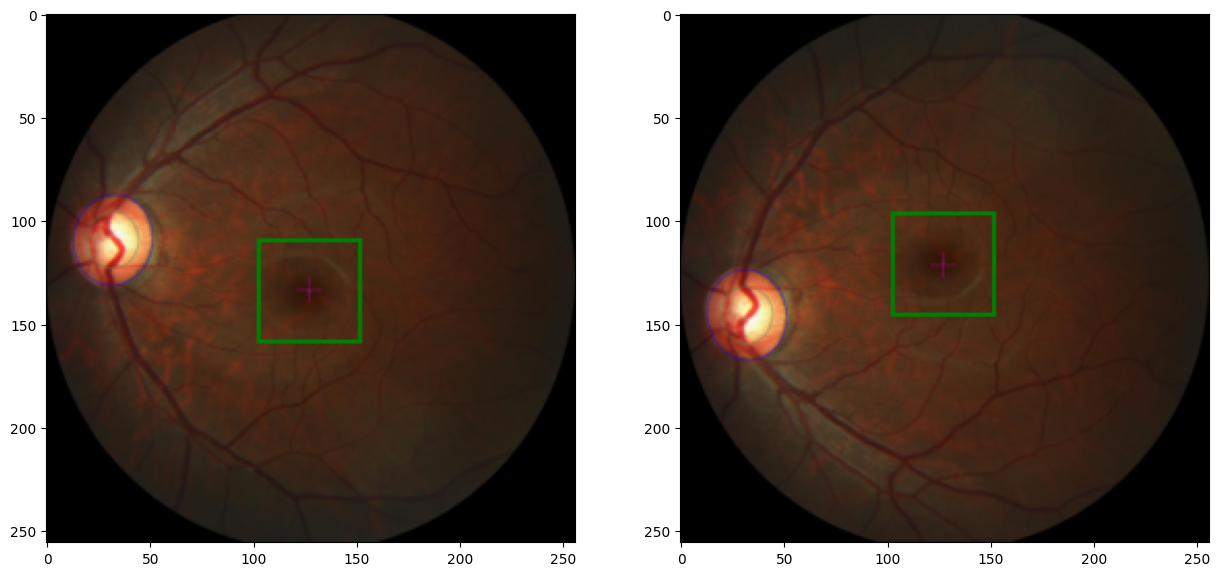

In [13]:
img, label=load_img_label(labels_df,1)
img_r,label_r=resize_images(img,label)
img_fv,label_fv=random_vflip(img_r,label_r)

plt.subplot(1,2,1)
show_img_label(img_r,label_r)
plt.subplot(1,2,2)
show_img_label(img_fv,label_fv)

plt.show()

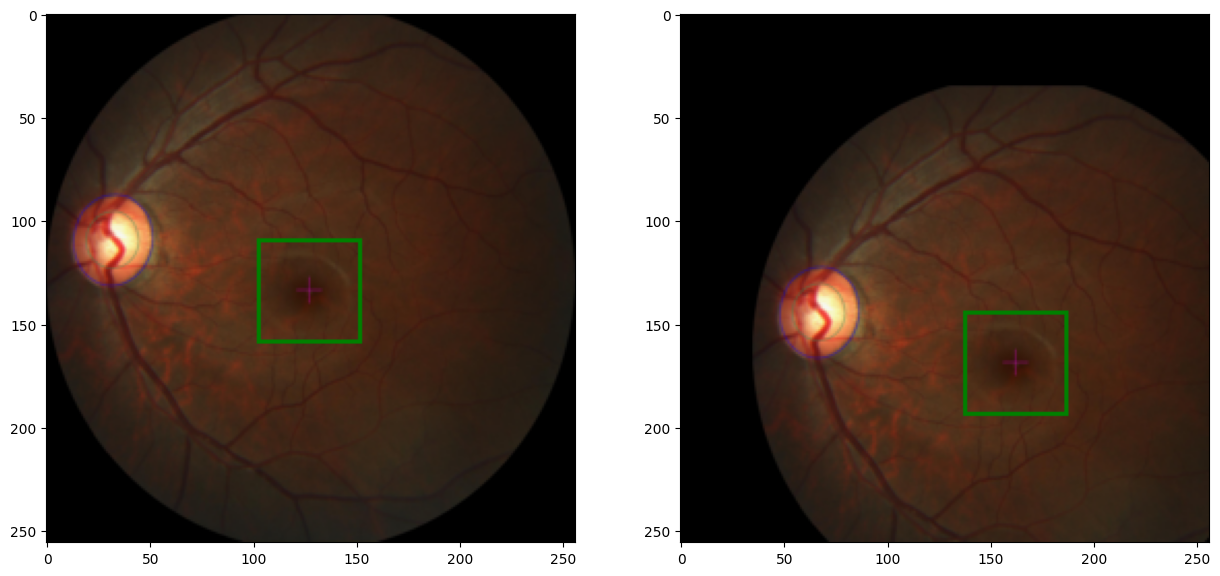

In [14]:
img,label=load_img_label(labels_df,1)

img_r,label_r=resize_images(img,label)

img_t,label_t=random_shift(img_r,label_r,max_translate=(0.5,0.5))

plt.subplot(1,2,1)
show_img_label(img_r,label_r)
plt.subplot(1,2,2)
show_img_label(img_t,label_t)
plt.show()

In [15]:
# random.seed(0)

img, label=load_img_label(labels_df,1)
params={
"target_size" : (256, 256),
"p_hflip" : 1.0,
"p_vflip" : 1.0,
"p_shift" : 1.0,
"max_translate": (0.2, 0.2),
}
img_t,label_t=transformer(img,label,params)

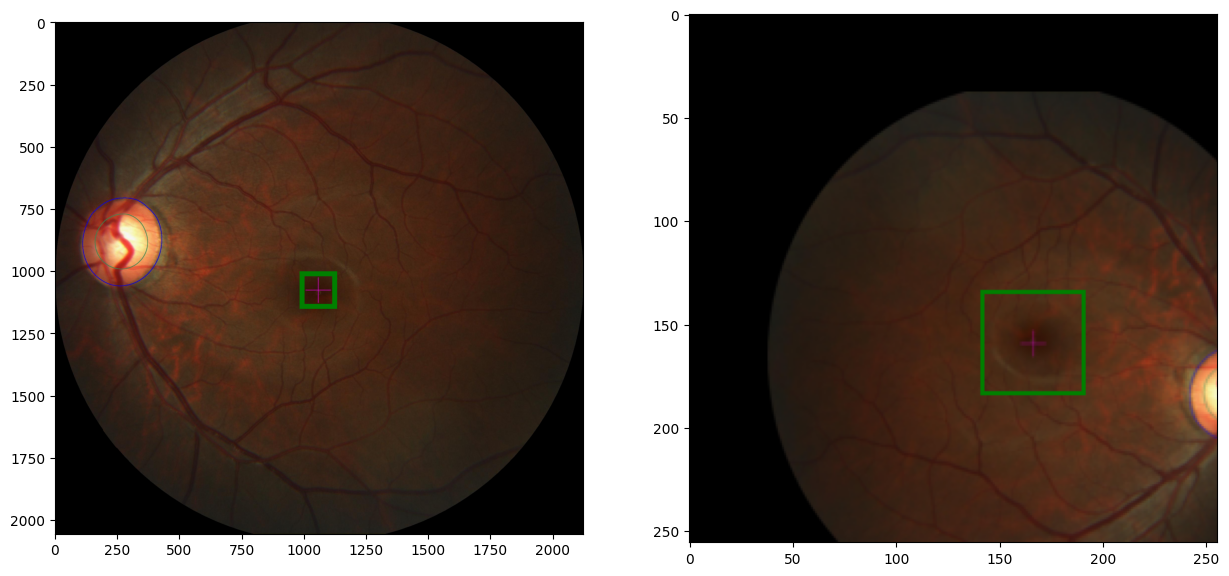

In [16]:
plt.subplot(1,2,1)
show_img_label(img,label,w_h=(150,150),thickness=20)
plt.subplot(1,2,2)
show_img_label(TF.to_pil_image(img_t),label_t)
plt.show()